In [1]:
# imports 
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map
from py_mods.src.SCF.scf_utils import _diagonalize_gram,  count_degen2
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

In [2]:
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"cc-pv5z",
}
for iteration in range(1,20):
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    RHF_cxt.verbose = False
    RHF_cxt.conv_type = None
    RHF_cxt.max_iter = iteration
    # RHF_cxt.theta = 0.1
    RHF_res = CS_RHF(RHF_cxt)
    # print('Number of orbitals is: ', len(RHF_res.X))
    mp_results = CS_MP2(RHF_res)

    MP2_error = (mymp.e_tot - mp_results.E_MP2)
    print(f'\nAt iteration {iteration}:')
    print('He/aug-cc-pvqz MP2 error:', MP2_error)
    print(f"max of imag part of coefficient matrix is {np.max(RHF_res.R_munu.imag):5e}")
    print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_res.P.imag))


At iteration 1:
He/aug-cc-pvqz MP2 error: (-2.852535096172178+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 2:
He/aug-cc-pvqz MP2 error: (-0.11153323928810988+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 3:
He/aug-cc-pvqz MP2 error: (-0.0014100641264205294+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 4:
He/aug-cc-pvqz MP2 error: (-4.179066481002636e-05+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 5:
He/aug-cc-pvqz MP2 error: (-2.8219252796723993e-06+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 6:
He/aug-cc-pvqz MP2 error: (-3.708392384282888e-07+0j)
max of imag part of coef

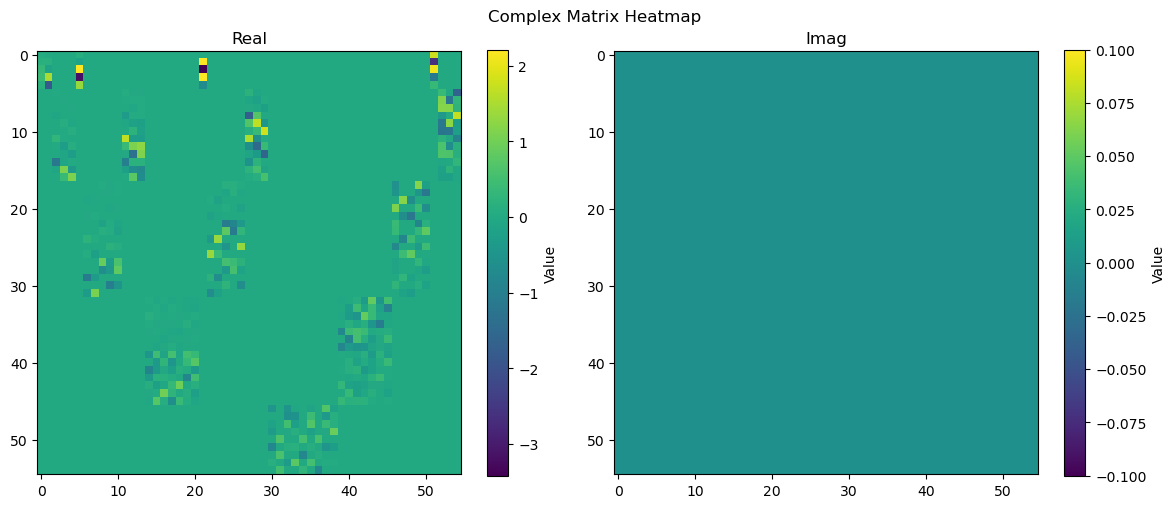

max of imag part of coefficient matrix is 0.000000e+00


In [3]:
plot_map(RHF_res.R_munu)
print(f"max of imag part of coefficient matrix is {np.max(RHF_res.R_munu.imag):5e}")

In [4]:
# implementation and calculation
RHF_iter_2 = RHF_context_from_pyscf(**pyscf_args)
RHF_iter_2.verbose = True
RHF_iter_2.conv_type = None
RHF_iter_2.max_iter = 2
RHF_iter_2.theta = 0.1
RHF_iter_2 = CS_RHF(RHF_iter_2)

print(f"\n\n\nMax of imag part of coefficient matrix is {np.max(RHF_iter_2.R_munu.imag):5e}")
print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_iter_2.P.imag))

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0            0.0000000000000000+0.0000000000000000j            0.0000000000000000+0.0000000000000000j     0.0000E+00
    1           -2.7500559638677600+0.0000162744490371j           -2.7500559638677600+0.0000162744490371j     2.0786E+00



Max of imag part of coefficient matrix is 7.178999e-01
Norm of the imaginay part of the density matrix is: 0.1491551027031825


In [5]:
# implementation and calculation
RHF_iter_3 = RHF_context_from_pyscf(**pyscf_args)
RHF_iter_3.verbose = True
RHF_iter_3.conv_type = None
RHF_iter_3.max_iter = 3
RHF_iter_3 = CS_RHF(RHF_iter_3)

print(f"\n\n\nMax of imag part of coefficient matrix is {np.max(RHF_iter_3.R_munu.imag):5e}")
print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_iter_3.P.imag))

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0            0.0000000000000000+0.0000000000000000j            0.0000000000000000+0.0000000000000000j     0.0000E+00
    1           -2.7500096308260251+0.0000000000000000j           -2.7500096308260251+0.0000000000000000j     2.0540E+00
    2           -2.8602516705773025+0.0000000000000000j           -0.1102420397512773+0.0000000000000000j     1.4406E-01



Max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0


Symmetric matrix: True


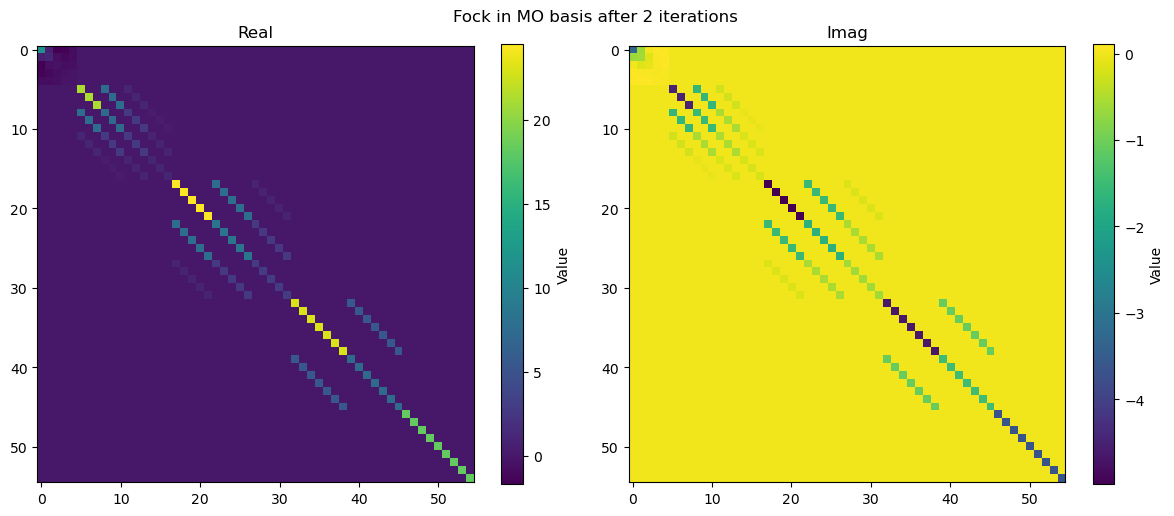

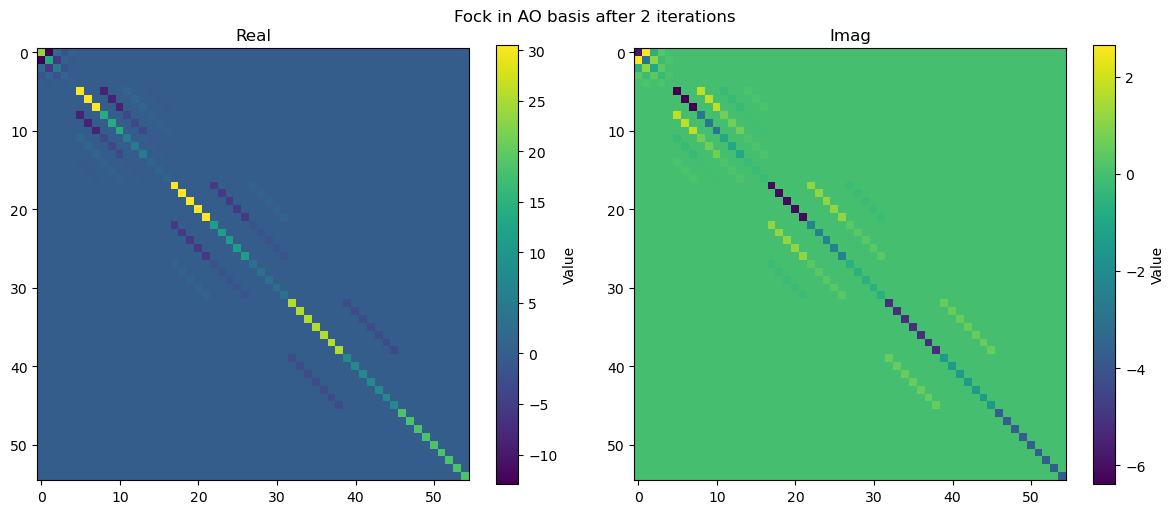

In [6]:
F_2 = RHF_iter_2.F_final
X = RHF_iter_2.X
F_2_ao = X.T @ F_2 @ X

print(f'Symmetric matrix: {np.allclose(F_2_ao.T, F_2_ao)}')

plot_map(F_2, title='Fock in MO basis after 2 iterations')
plot_map(F_2_ao, title='Fock in AO basis after 2 iterations')


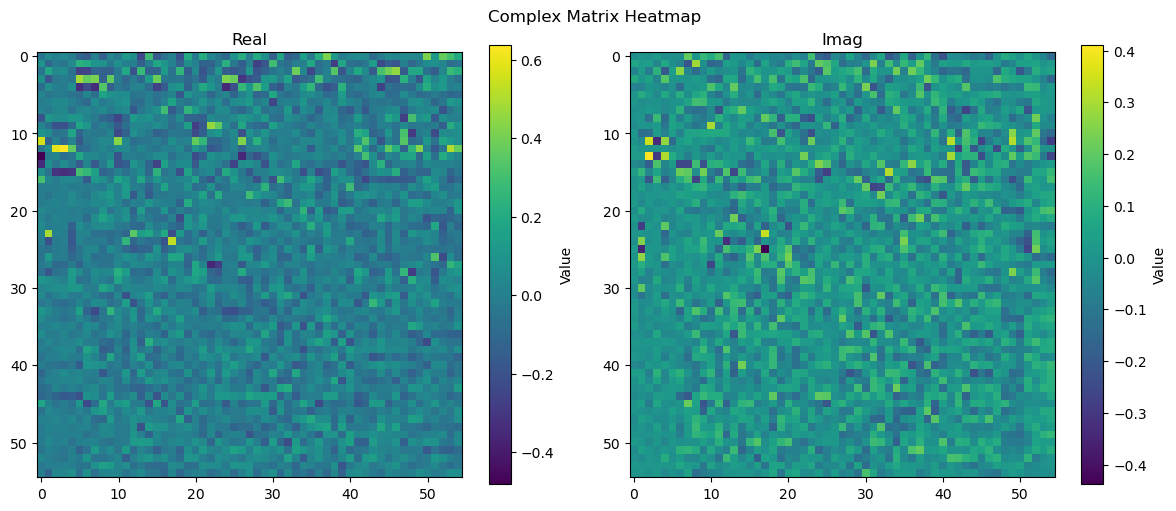

[-1.95525486-0.07436912j -0.52288274-1.81434409j  1.9559649 +0.29910494j
  1.87453283-0.28747976j  1.48319783+1.00484646j -1.67461366+0.12481434j
 -0.37270542+1.37729116j -0.89934688+1.04537791j  0.1325069 +1.30698063j
  0.62879583+1.13619829j -1.45260013-0.26479642j -0.41373189+1.07876493j
 -0.22637797+1.08879183j  0.15724909+1.04823201j  0.2470964 +0.98719025j
 -1.39226297+0.12994067j -0.62646811+0.87568182j -0.27370955+0.80820512j
 -0.92442658+0.71025553j -0.80571137+0.64617221j -1.29521771+0.04303997j
 -1.00423685+0.40761103j -1.13980338+0.06663784j -0.96329231+0.24036599j
 -0.64646348-1.32858376j -0.99480542-0.9058325j  -0.90457826+0.00728412j
 -1.0782305 -0.27806283j -0.97682487-0.36757529j -0.85555478-0.75918399j
 -0.57603434-1.06520833j -0.67861657-0.66133858j -0.35451341-0.93896601j
  0.12425532-1.30935951j -0.15012555-1.15553251j  0.98712674+0.98657499j
  0.3447542 -1.16286012j  0.09455181-0.92222118j  0.90843975-1.08582452j
  0.69816002-1.07355339j  0.6860984 +0.6952674j   1

In [7]:
eval, evec = np.linalg.eig(RHF_iter_2.R_munu)
R_prime, L_prime, e_values, C_prime = _diagonalize_gram(RHF_iter_2.R_munu)

plot_map(evec)
print(eval)